[Home](../../README.md)

### Data Wrangling

I will be using this notebook for data wrangling through [Pandas](https://pandas.pydata.org/). I will be analysing my data and manipulating it based on the analysis. My final wrangled data will be saved at the end to a new csv file, ready for the next stage in my model development, feature engineering.

In [1]:
# Import frameworks
import pandas as pd

In [2]:
data_frame = pd.read_csv("2.1.2.minecraft_100x100.csv")

#### Checking for null values

I'm using `isnull().sum()` to check for any null values throughout my database, as null values can cause runtime errors and skew results.

In [3]:
pd.set_option("display.max_rows", None)
data_frame.isnull().sum()

chunk_x                                       0
chunk_z                                       0
dominant_biome                                0
minecraft:acacia_leaves                       0
minecraft:acacia_log                          0
minecraft:air                                 0
minecraft:amethyst_block                      0
minecraft:amethyst_cluster                    0
minecraft:andesite                            0
minecraft:azalea                              0
minecraft:azalea_leaves                       0
minecraft:azure_bluet                         0
minecraft:barrel                              0
minecraft:bedrock                             0
minecraft:bee_nest                            0
minecraft:beetroots                           0
minecraft:bell                                0
minecraft:big_dripleaf                        0
minecraft:big_dripleaf_stem                   0
minecraft:birch_fence                         0
minecraft:birch_leaves                  

#### Replace data

In order to improve the readibility and optimization of my targets and features, I am going to remove the common prefix "minecraft:" from each column.

In [4]:
data_frame['dominant_biome'] = data_frame['dominant_biome'].apply(lambda x: x.replace('minecraft:', ''))
data_frame['dominant_biome'].head()

0    cold_ocean
1    cold_ocean
2    cold_ocean
3    cold_ocean
4    cold_ocean
Name: dominant_biome, dtype: str

In [5]:
data_frame.columns = data_frame.columns.str.replace("minecraft:", "", regex=False)
data_frame.head()

,chunk_x,chunk_z,dominant_biome,acacia_leaves,acacia_log,air,amethyst_block,amethyst_cluster,andesite,azalea,...,white_carpet,white_concrete,white_stained_glass,white_terracotta,white_wool,wildflowers,yellow_bed,yellow_carpet,yellow_glazed_terracotta,yellow_wool
0,0,0,cold_ocean,0,0,66914,0,0,1086,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,cold_ocean,0,0,67433,0,0,1274,0,...,0,0,0,0,0,0,0,0,0,0
2,1,1,cold_ocean,0,0,67102,0,0,873,1,...,0,0,0,0,0,0,0,0,0,0
3,0,1,cold_ocean,0,0,67086,0,0,1174,10,...,0,0,0,0,0,0,0,0,0,0
4,-1,1,cold_ocean,0,0,66035,0,0,1003,0,...,0,0,0,0,0,0,0,0,0,0


#### Drop unecessary columns

Many of my features are not necessary for the algorithms prediction, either being very rare (only in one or two chunks), or are in every single chunk no matter what (e.g. bedrock). I will also be dropping the chunk coordinates as they are unnecessary for the function of my model.

In [6]:
df = pd.read_csv("2.1.2.minecraft_100x100.csv")
zero_counts = (df == 0).sum(axis=0)
zero_summary = pd.DataFrame({"Column": df.columns, "Zero Count": zero_counts.values})
zero_summary = zero_summary.sort_values("Zero Count", ascending=True)
print(zero_summary.to_string(index=False))

                                    Column  Zero Count
                            dominant_biome           0
                       minecraft:deepslate           0
                          minecraft:gravel           0
                           minecraft:stone           0
                         minecraft:bedrock           0
                             minecraft:air           0
                      minecraft:copper_ore           3
                         minecraft:diorite           3
                            minecraft:tuff           3
                        minecraft:andesite           4
                         minecraft:granite           4
          minecraft:deepslate_redstone_ore           6
                        minecraft:iron_ore           7
           minecraft:deepslate_diamond_ore          23
              minecraft:deepslate_iron_ore          24
                            minecraft:dirt          29
              minecraft:deepslate_gold_ore          58
          

I have attempted to filter features by the amount of 0 values to determine their importance, but I have decided that I will need to manually select which features to keep based on my domain knowledge.

In [7]:
# chunk_x, chunk_z, dominant_biome, air, dirt, water, short_grass, grass_block, lava, sand, tall_seagrass, oak_leaves, birch_leaves, oak_log, tall_grass, birch_log, kelp, kelp_plant, oak_planks, oak_fence, dark_oak_log, dark_oak_leaves, spruce_leaves, spruce_log, bush, sandstone, brown_mushroom, dandelion, podzol, red_mushroom_block, mushroom_stem, poppy, coarse_dirt, oxeye_daisy, cornflower, azure_bluet, emerald_ore, lily_pad, barrel, sugar_cane, red_mushroom, lilac, lily_of_the_valley, rose_bush, peony, sweet_berry_bush, bee_nest, pumpkin, snow, acacia_leaves, acacia_log, blue_orchid

columns_to_keep = [
    "dominant_biome",
    "air",
    "dirt",
    "water",
    "short_grass",
    "grass_block",
    "lava",
    "sand",
    "tall_seagrass",
    "oak_leaves",
    "birch_leaves",
    "oak_log",
    "tall_grass",
    "birch_log",
    "kelp",
    "kelp_plant",
    "oak_planks",
    "oak_fence",
    "dark_oak_log",
    "dark_oak_leaves",
    "spruce_leaves",
    "spruce_log",
    "bush",
    "sandstone",
    "brown_mushroom",
    "dandelion",
    "podzol",
    "red_mushroom_block",
    "mushroom_stem",
    "poppy",
    "coarse_dirt",
    "oxeye_daisy",
    "cornflower",
    "azure_bluet",
    "emerald_ore",
    "lily_pad",
    "barrel",
    "sugar_cane",
    "red_mushroom",
    "lilac",
    "lily_of_the_valley",
    "rose_bush",
    "peony",
    "sweet_berry_bush",
    "bee_nest",
    "pumpkin",
    "snow",
    "acacia_leaves",
    "blue_orchid",
]

data_frame = data_frame[columns_to_keep]
data_frame.head()

,dominant_biome,air,dirt,water,short_grass,grass_block,lava,sand,tall_seagrass,oak_leaves,...,lilac,lily_of_the_valley,rose_bush,peony,sweet_berry_bush,bee_nest,pumpkin,snow,acacia_leaves,blue_orchid
0,cold_ocean,66914,309,3509,0,0,1,0,30,0,...,0,0,0,0,0,0,0,0,0,0
1,cold_ocean,67433,275,4174,0,0,0,0,16,0,...,0,0,0,0,0,0,0,0,0,0
2,cold_ocean,67102,407,4202,6,0,0,0,14,0,...,0,0,0,0,0,0,0,0,0,0
3,cold_ocean,67086,121,3825,34,0,0,96,16,0,...,0,0,0,0,0,0,0,0,0,0
4,cold_ocean,66035,400,3889,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


#### Remove outliers

My algorithm to remove outliers is fairly complex, as my data requires that I analyse outliers in featuers *per* target, otherwise valid data could be removed. To remove these outliers, I loop through each block through each biome, then find the bottom and top 10% of values, and calculate IQR from that data. Next, we skip any instances where IQR = 0, as this means there is very little to no variation, usually for very rare blocks, and any non-zero value would be flagged as an outlier. This means that valid rows would be removed if this exception wasn't in place. Then we calculate threshholds, and stop the lower at 0, since negative values aren't possible, and then find our outliers. Finally, returning our dataframe missing all rows with outliers

In [8]:
# get the inter-quartile range per biome for relevant block features
# Outliers are defined relative to each biome's distribution
# When IQR is 0, blocks can be skipped as they are unnecessary to remove
# Algorithm shouldn't be biased from biome overlap, but should still be able to handle occasional misplaced blocks

blocks = [
    "air",
    "dirt",
    "water",
    "short_grass",
    "grass_block",
    "lava",
    "sand",
    "tall_seagrass",
    "oak_leaves",
    "birch_leaves",
    "oak_log",
    "tall_grass",
    "birch_log",
    "kelp",
    "kelp_plant",
    "oak_planks",
    "oak_fence",
    "dark_oak_log",
    "dark_oak_leaves",
    "spruce_leaves",
    "spruce_log",
    "bush",
    "sandstone",
    "brown_mushroom",
    "dandelion",
    "podzol",
    "red_mushroom_block",
    "mushroom_stem",
    "poppy",
    "coarse_dirt",
    "oxeye_daisy",
    "cornflower",
    "azure_bluet",
    "emerald_ore",
    "lily_pad",
    "barrel",
    "sugar_cane",
    "red_mushroom",
    "lilac",
    "lily_of_the_valley",
    "rose_bush",
    "peony",
    "sweet_berry_bush",
    "bee_nest",
    "pumpkin",
    "snow",
    "acacia_leaves",
    "blue_orchid",
]


def filter_biome_outliers(df, blocks):
    mask = pd.Series([True] * len(df), index=df.index)
    for block in blocks:
        for biome, group in df.groupby("dominant_biome"):
            Q1 = group[block].quantile(0.10)
            Q3 = group[block].quantile(0.90)
            IQR = Q3 - Q1
            # Skip sparse blocks where IQR=0 — every non-zero value would be flagged
            if IQR == 0:
                print(f"Skipping {block} in {biome} as IQR = 0")
                continue
            lower = max(0, Q1 - IQR)  # clamp to 0, block counts can't be negative
            upper = Q3 + IQR
            outlier_mask = (df.index.isin(group.index)) & (
                (df[block] < lower) | (df[block] > upper)
            )
            removed = outlier_mask.sum()
            if removed > 0:
                print(
                    f"Removing {removed} outliers for {block} in {biome} (threshold: <{lower:.2f} or >{upper:.2f})"
                )
            mask &= ~outlier_mask
    return df[mask]


rows_before = len(data_frame)
data_frame = filter_biome_outliers(data_frame, blocks)
print(
    f"\nRows before: {rows_before} | Rows after: {len(data_frame)} | Removed: {rows_before - len(data_frame)}"
)

Removing 8 outliers for air in beach (threshold: <61534.00 or >72985.00)
Removing 4 outliers for air in birch_forest (threshold: <56417.60 or >78698.00)
Removing 46 outliers for air in cold_ocean (threshold: <62125.60 or >73325.80)
Removing 22 outliers for air in dark_forest (threshold: <58098.30 or >74514.00)
Removing 1 outliers for air in deep_cold_ocean (threshold: <58679.10 or >80029.50)
Removing 2 outliers for air in deep_ocean (threshold: <62593.20 or >72925.50)
Removing 22 outliers for air in forest (threshold: <56924.00 or >75823.70)
Removing 16 outliers for air in ocean (threshold: <62873.70 or >71671.50)
Removing 7 outliers for air in old_growth_birch_forest (threshold: <59066.00 or >74957.60)
Removing 2 outliers for air in old_growth_pine_taiga (threshold: <52939.00 or >74887.00)
Removing 21 outliers for air in plains (threshold: <51585.40 or >81869.20)
Removing 22 outliers for air in river (threshold: <62184.10 or >73007.80)
Removing 5 outliers for air in swamp (threshold: 

#### Scaling features to a common range

Scaling the features makes it easier for machine learning algorithms to find the optimal solution, as the different scales of the features do not influence them.

In [9]:
# Record original min/max before scaling
scaling_params = {}
for block in blocks:
    scaling_params[block] = {
        "min": data_frame[block].min(),
        "max": data_frame[block].max(),
    }

# Min-Max scale all block features to [0, 1] range
for block in blocks:
    min_val = scaling_params[block]["min"]
    max_val = scaling_params[block]["max"]
    if max_val - min_val > 0:
        data_frame[block] = (data_frame[block] - min_val) / (max_val - min_val)

# Display scaling params as a readable table for noting in 2.1.2.data.records
scaling_df = pd.DataFrame(scaling_params).T
print(scaling_df.to_string())

                      min    max
air                 50627  81401
dirt                    0   1970
water                   0  12165
short_grass             0    131
grass_block             0    473
lava                    0    512
sand                    0   1390
tall_seagrass           0    114
oak_leaves              0    748
birch_leaves            0    476
oak_log                 0     69
tall_grass              0     48
birch_log               0     70
kelp                    0     95
kelp_plant              0    559
oak_planks              0    135
oak_fence               0     64
dark_oak_log            0    276
dark_oak_leaves         0    659
spruce_leaves           0   1196
spruce_log              0    311
bush                    0      8
sandstone               0   1154
brown_mushroom          0     35
dandelion               0      9
podzol                  0    393
red_mushroom_block      0     90
mushroom_stem           0     12
poppy                   0     17
coarse_dir

#### Correlation heatmap

I'm using a correlation heatmap at the end of my wrangling to find features that have very little correlaton to any target. This is to remove unecessary features and simplify the data so the algorithm can process it faster and find corellation more easily.

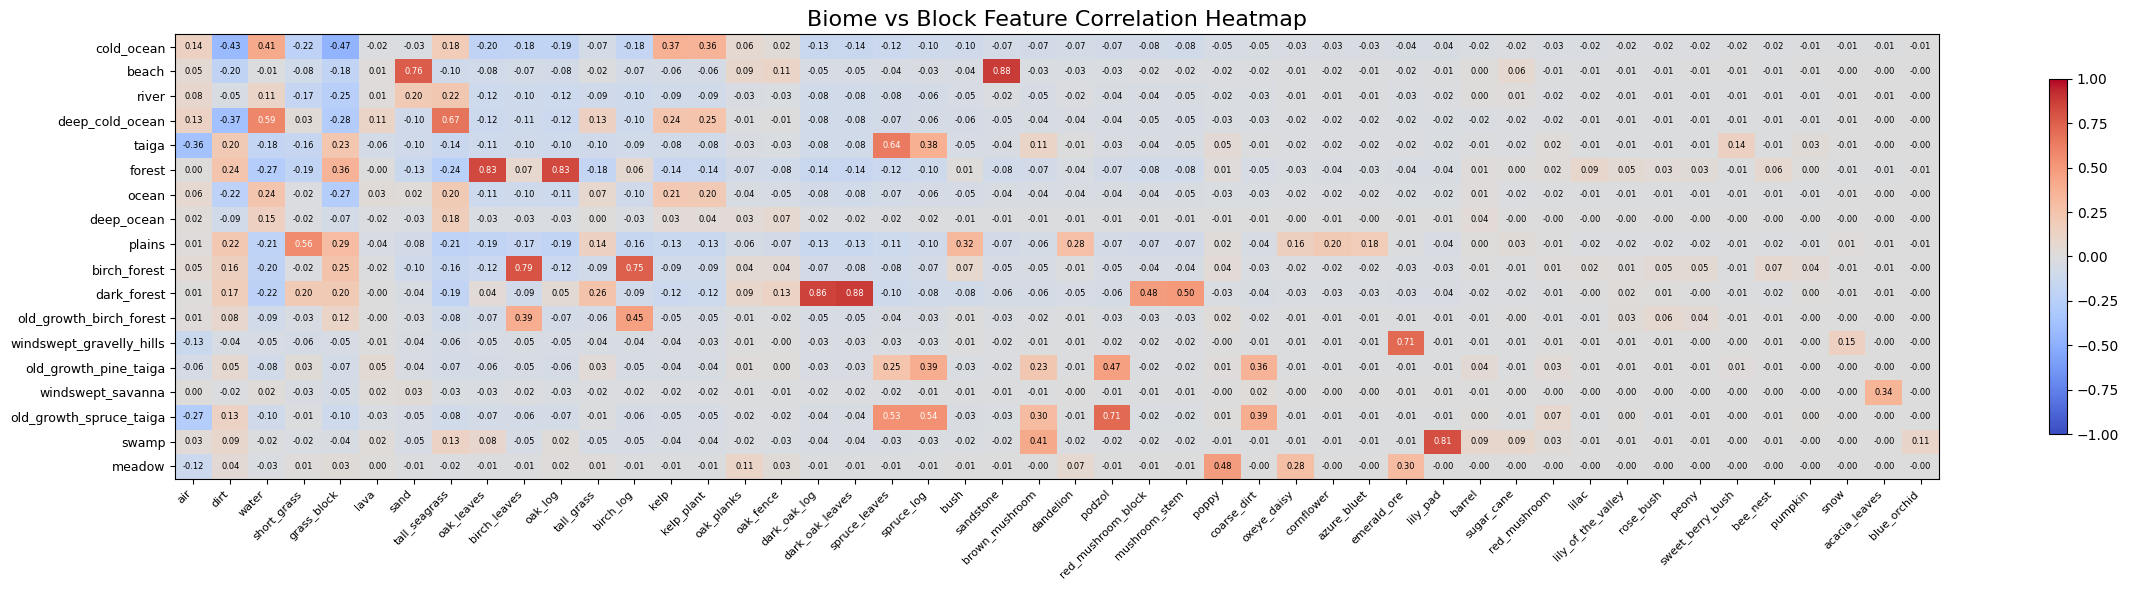

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Encode dominant_biome as numeric for correlation
biome_encoded = data_frame["dominant_biome"].astype("category").cat.codes

# Compute correlation of each block with each biome (one-hot encoded)
biomes = data_frame["dominant_biome"].unique()
biome_block_corr = pd.DataFrame(index=biomes, columns=blocks, dtype=float)

for biome in biomes:
    # Create binary column: 1 if this biome, 0 otherwise
    biome_indicator = (data_frame["dominant_biome"] == biome).astype(int)
    for block in blocks:
        biome_block_corr.loc[biome, block] = biome_indicator.corr(data_frame[block])

fig, ax = plt.subplots(figsize=(24, 6))

# Plot heatmap using imshow
im = ax.imshow(
    biome_block_corr.values.astype(float),
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto",
)

# Add colourbar
fig.colorbar(im, ax=ax, shrink=0.8)

# Annotate each cell with its correlation value
for i in range(len(biomes)):
    for j in range(len(blocks)):
        val = biome_block_corr.iloc[i, j]
        text_colour = "white" if abs(val) > 0.5 else "black"
        ax.text(
            j, i, f"{val:.2f}", ha="center", va="center", fontsize=6, color=text_colour
        )

# Set tick labels
ax.set_xticks(range(len(blocks)))
ax.set_yticks(range(len(biomes)))
ax.set_xticklabels(blocks, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(biomes, fontsize=9)

ax.set_title("Biome vs Block Feature Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

Based on my analysis heatmap, I'm doing a 'second round' of removal of certain features, only keeping those with a correlation to any biome above 0.25.

In [11]:
columns_to_keep = [
    "dominant_biome",
    "air",
    "dirt",
    "water",
    "short_grass",
    "grass_block",
    "sand",
    "tall_seagrass",
    "oak_leaves",
    "birch_leaves",
    "oak_log",
    "tall_grass",
    "birch_log",
    "kelp",
    "kelp_plant",
    "dark_oak_log",
    "dark_oak_leaves",
    "spruce_leaves",
    "spruce_log",
    "bush",
    "sandstone",
    "brown_mushroom",
    "dandelion",
    "podzol",
    "red_mushroom_block",
    "mushroom_stem",
    "poppy",
    "coarse_dirt",
    "oxeye_daisy",
    "emerald_ore",
    "lily_pad",
    "snow",
    "acacia_leaves",
]

data_frame = data_frame[columns_to_keep]
data_frame.head()

,dominant_biome,air,dirt,water,short_grass,grass_block,sand,tall_seagrass,oak_leaves,birch_leaves,...,podzol,red_mushroom_block,mushroom_stem,poppy,coarse_dirt,oxeye_daisy,emerald_ore,lily_pad,snow,acacia_leaves
0,cold_ocean,0.529245,0.156853,0.288450,0.000000,0.0,0.000000,0.263158,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,cold_ocean,0.546110,0.139594,0.343115,0.000000,0.0,0.000000,0.140351,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,cold_ocean,0.535355,0.206599,0.345417,0.045802,0.0,0.000000,0.122807,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,cold_ocean,0.534835,0.061421,0.314427,0.259542,0.0,0.069065,0.140351,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,cold_ocean,0.500682,0.203046,0.319688,0.007634,0.0,0.000719,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Then, I'll check my heatmap once more to confirm I have all the final features I need.

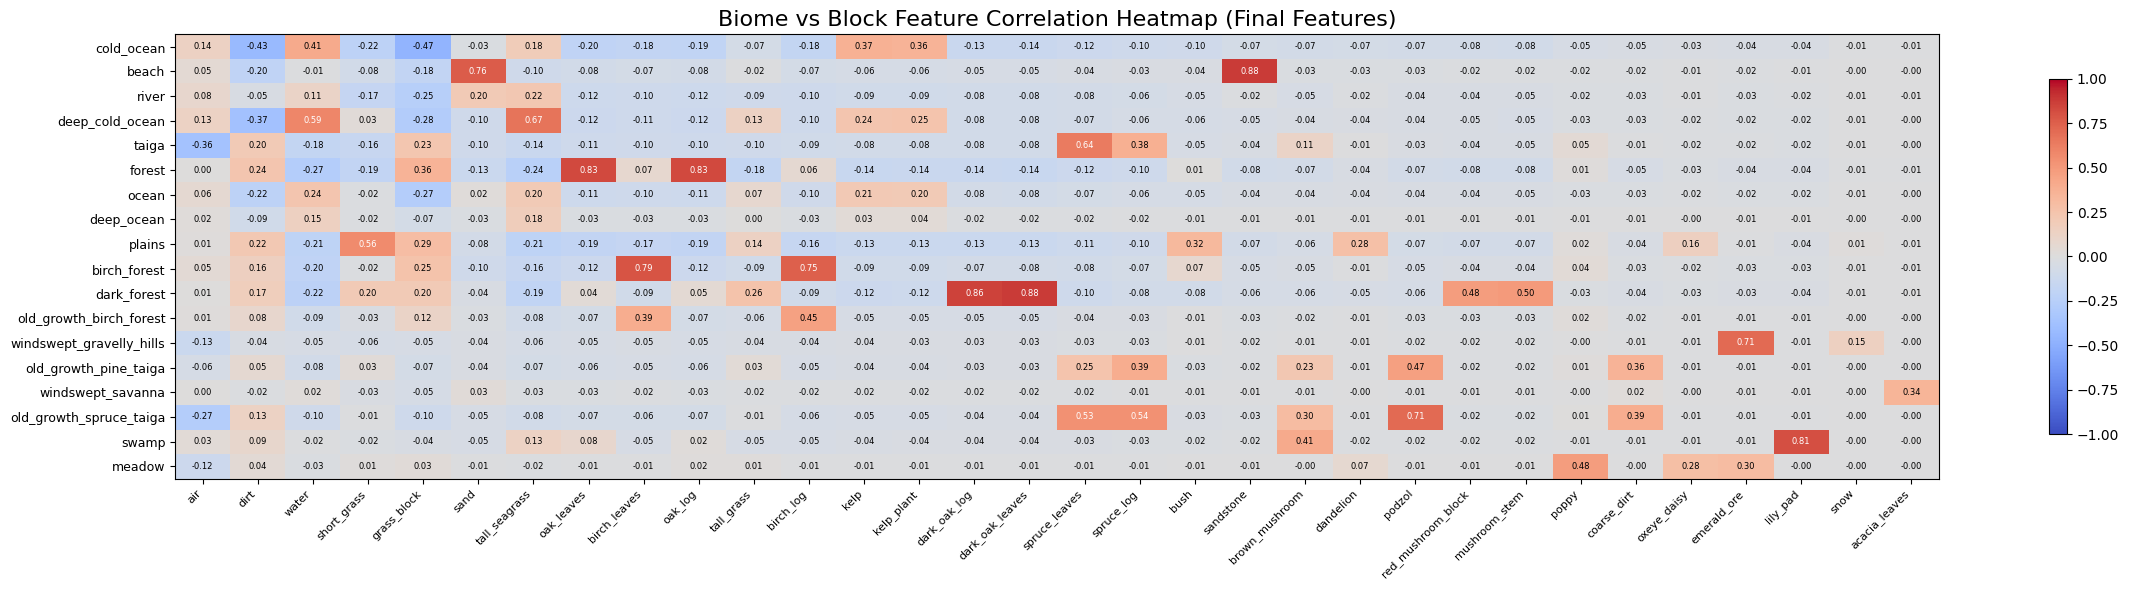

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Use only block columns present in the filtered dataframe
filtered_blocks = [
    col
    for col in columns_to_keep
    if col not in ["chunk_x", "chunk_z", "dominant_biome"]
]

# Compute correlation of each block with each biome (one-hot encoded)
biomes = data_frame["dominant_biome"].unique()
biome_block_corr = pd.DataFrame(index=biomes, columns=filtered_blocks, dtype=float)

for biome in biomes:
    biome_indicator = (data_frame["dominant_biome"] == biome).astype(int)
    for block in filtered_blocks:
        biome_block_corr.loc[biome, block] = biome_indicator.corr(data_frame[block])

fig, ax = plt.subplots(figsize=(24, 6))

im = ax.imshow(
    biome_block_corr.values.astype(float),
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto",
)

fig.colorbar(im, ax=ax, shrink=0.8)

for i in range(len(biomes)):
    for j in range(len(filtered_blocks)):
        val = biome_block_corr.iloc[i, j]
        text_colour = "white" if abs(val) > 0.5 else "black"
        ax.text(
            j, i, f"{val:.2f}", ha="center", va="center", fontsize=6, color=text_colour
        )

ax.set_xticks(range(len(filtered_blocks)))
ax.set_yticks(range(len(biomes)))
ax.set_xticklabels(filtered_blocks, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(biomes, fontsize=9)

ax.set_title("Biome vs Block Feature Correlation Heatmap (Final Features)", fontsize=16)
plt.tight_layout()
plt.show()

#### Save the wrangled data to CSV

In [13]:
data_frame.to_csv('../2.2.Feature_Engineering/2.2.1.wrangled_data.csv', index=False)